In [ ]:
#Name: Aashish Singh , Section: Q , Roll No.: 20

In [ ]:
"""
Problem Statement: 15
Consider a dataset containing records related to customer purchasing 
behavior. The dataset includes multiple numerical features describing 
customer demographics and spending patterns.The program should perform 
the following tasks: 
 
i. Read the given dataset into a dataframe. 
ii. Perform necessary data preprocessing and feature scaling. 
iii. Apply the K-Means Clustering algorithm on the dataset for different 
values of K. 
iv. Determine the optimal number of clusters using the Elbow Method. 
v. Validate the clustering results using the Silhouette Score. 
vi. Perform clustering using the optimal value of K and assign cluster labels 
to the data points. 
vii. Visualize the formed clusters and analyze the clustering results.
"""

In [1]:
#Importing libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
# Creating dataset
np.random.seed(42)
n = 200

age = np.random.randint(18, 65, n)
income = np.random.randint(20000, 100000, n)
spending_score = np.random.randint(1, 100, n)
savings = np.random.randint(5000, 50000, n)

data = pd.DataFrame({
    "age": age,
    "income": income,
    "spending_score": spending_score,
    "savings": savings
})

data.to_csv("customer_data.csv", index=False)
print("Dataset created!\n")

Dataset created!



In [3]:
# i.) Read the dataset
df = pd.read_csv('customer_data.csv') 

In [4]:
# ii.) Data Preprocessing and Feature Scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df) 

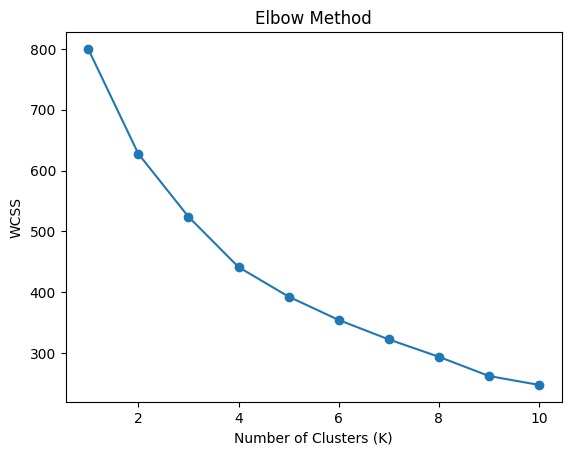

In [5]:
# iii) & iv.) Apply K-Means and find optimal K using Elbow Method
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

# Plot Elbow Graph
plt.figure()
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

In [6]:
# v.) Validate results using Silhouette Score
print("\nSilhouette Scores:")
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(scaled_data)
    score = silhouette_score(scaled_data, labels)
    print(f"K = {k}, Score = {score:.3f}")


Silhouette Scores:
K = 2, Score = 0.209
K = 3, Score = 0.202
K = 4, Score = 0.218
K = 5, Score = 0.221
K = 6, Score = 0.224
K = 7, Score = 0.217
K = 8, Score = 0.221
K = 9, Score = 0.236
K = 10, Score = 0.230


In [7]:
# vi.) Perform clustering using the optimal K (assuming K=4 based on Elbow/Silhouette)
optimal_k = 3

kmeans = KMeans(n_clusters=optimal_k, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

df["Cluster"] = clusters

print("\nClustered Data:\n", df.head())


Clustered Data:
    age  income  spending_score  savings  Cluster
0   56   72733              90    40909        1
1   46   85318              62    28803        2
2   32   43664              23    24870        0
3   60   87172               9    39578        2
4   25   46736              12    11588        0


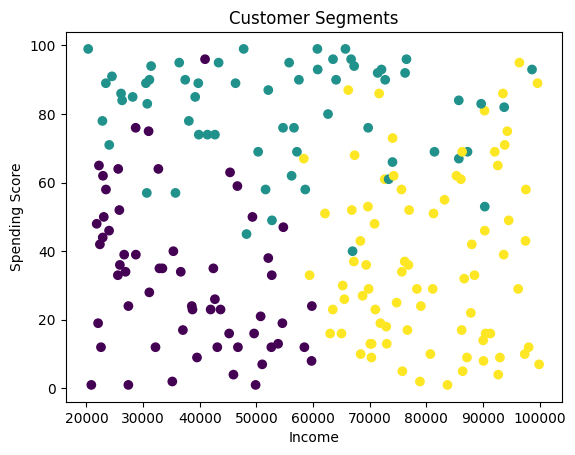

In [8]:
# vii. Visualize the clusters
plt.figure()
plt.scatter(df["income"], df["spending_score"], c=df["Cluster"])
plt.title("Customer Segments")
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.show()